In [45]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
close_prices = pd.read_csv("../data/ten_stocks_wide.csv", index_col = "Date", parse_dates = True)
print("Shape :", close_prices.shape)
close_prices.head()

Shape : (1238, 10)


,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,MARUTI.NS,ONGC.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,
2020-01-01,605.529358,1749.931396,519.138000,633.151123,333.417084,6945.335449,85.371376,672.216125,1841.149780,113.709183
2020-01-02,609.389160,1751.286865,522.861572,631.303650,332.919128,6962.575195,85.773300,683.660217,1832.698120,113.984612
2020-01-03,600.698792,1741.708374,521.169006,641.013367,330.041168,6890.763672,86.041237,684.484009,1869.221680,115.270004
2020-01-06,587.698853,1730.864502,508.450531,634.869690,329.134949,6689.528809,84.567574,668.609314,1869.052368,115.751991
2020-01-07,597.004761,1735.608643,505.742432,625.460693,332.779724,6719.166016,84.232666,678.895691,1873.638794,117.152122


In [47]:
daily_returns = (close_prices.pct_change()*100).dropna()
print(daily_returns)

            HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  KOTAKBANK.NS  \
Date                                                                           
2020-01-02     0.637426       0.077458      0.717260 -0.291790     -0.149349   
2020-01-03    -1.426079      -0.546940     -0.323712  1.538042     -0.864462   
2020-01-06    -2.164136      -0.622600     -2.440374 -0.958432     -0.274578   
2020-01-07     1.583448       0.274091     -0.532618 -1.482036      1.107380   
2020-01-08    -0.261774       0.450362      0.583291 -1.332592     -0.957602   
...                 ...            ...           ...       ...           ...   
2024-12-24    -0.161022      -0.143231      0.034699 -0.792495      0.211988   
2024-12-26    -0.408764      -0.119887      0.007700 -0.086429      0.214405   
2024-12-27     0.418822       0.364377      0.786231  0.490192      0.405075   
2024-12-30    -1.131657       0.096103     -0.986581 -0.560840     -1.090978   
2024-12-31    -0.284044      -0.710473  

In [48]:
rolling_return = daily_returns.rolling(window=30).mean().dropna()
print(rolling_return)

            HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  KOTAKBANK.NS  \
Date                                                                           
2020-02-12    -0.070587       0.529858      0.086398  0.203673      0.092733   
2020-02-13    -0.112117       0.561267      0.012122  0.261199      0.048923   
2020-02-14    -0.123789       0.538114      0.052487  0.185527      0.060281   
2020-02-17    -0.057665       0.555246      0.108182  0.230190      0.089561   
2020-02-18    -0.121127       0.519176      0.123474  0.314215      0.052451   
...                 ...            ...           ...       ...           ...   
2024-12-24     0.089138      -0.228423      0.104564  0.151083      0.010698   
2024-12-26     0.052999      -0.210287      0.077150  0.093282      0.021281   
2024-12-27     0.157733      -0.158600      0.099944  0.094031      0.077980   
2024-12-30     0.191501      -0.160068      0.111394  0.076050      0.106580   
2024-12-31     0.159431      -0.081314  

In [49]:
volatility = daily_returns.rolling(window=30).std().dropna()
print(volatility)

            HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  KOTAKBANK.NS  \
Date                                                                           
2020-02-12     1.240899       1.677891      1.393604  1.396534      1.594128   
2020-02-13     1.237230       1.677949      1.417989  1.410891      1.618877   
2020-02-14     1.251621       1.698436      1.425316  1.400890      1.613434   
2020-02-17     1.191046       1.688889      1.355481  1.384423      1.615118   
2020-02-18     1.150624       1.706563      1.350582  1.353060      1.603674   
...                 ...            ...           ...       ...           ...   
2024-12-24     1.218748       1.311722      0.949426  1.432358      0.964746   
2024-12-26     1.216837       1.309252      0.939575  1.404604      0.965196   
2024-12-27     1.099176       1.299969      0.948462  1.404817      0.934630   
2024-12-30     1.039971       1.299645      0.932543  1.409789      0.882116   
2024-12-31     1.039284       1.183426  

In [50]:
momentum_score = rolling_return / (volatility + 1e-9)

In [51]:
print(momentum_score.round(2))
print("\nShape:", momentum_score.shape)

            HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  INFY.NS  KOTAKBANK.NS  \
Date                                                                          
2020-02-12        -0.06           0.32          0.06     0.15          0.06   
2020-02-13        -0.09           0.33          0.01     0.19          0.03   
2020-02-14        -0.10           0.32          0.04     0.13          0.04   
2020-02-17        -0.05           0.33          0.08     0.17          0.06   
2020-02-18        -0.11           0.30          0.09     0.23          0.03   
...                 ...            ...           ...      ...           ...   
2024-12-24         0.07          -0.17          0.11     0.11          0.01   
2024-12-26         0.04          -0.16          0.08     0.07          0.02   
2024-12-27         0.14          -0.12          0.11     0.07          0.08   
2024-12-30         0.18          -0.12          0.12     0.05          0.12   
2024-12-31         0.15          -0.07          0.07

In [52]:
latest = momentum_score.iloc[-1]
print(latest.sort_values(ascending = False).round(2))

WIPRO.NS         0.16
KOTAKBANK.NS     0.16
HDFCBANK.NS      0.15
ICICIBANK.NS     0.07
INFY.NS          0.03
TCS.NS          -0.02
ONGC.NS         -0.04
MARUTI.NS       -0.04
HINDUNILVR.NS   -0.07
RELIANCE.NS     -0.10
Name: 2024-12-31 00:00:00, dtype: float64


In [56]:
hottest = latest.sort_values(ascending = False).round(2)

In [58]:
top_3_hottest = hottest.head(3)
top_3_hottest

WIPRO.NS        0.16
KOTAKBANK.NS    0.16
HDFCBANK.NS     0.15
Name: 2024-12-31 00:00:00, dtype: float64

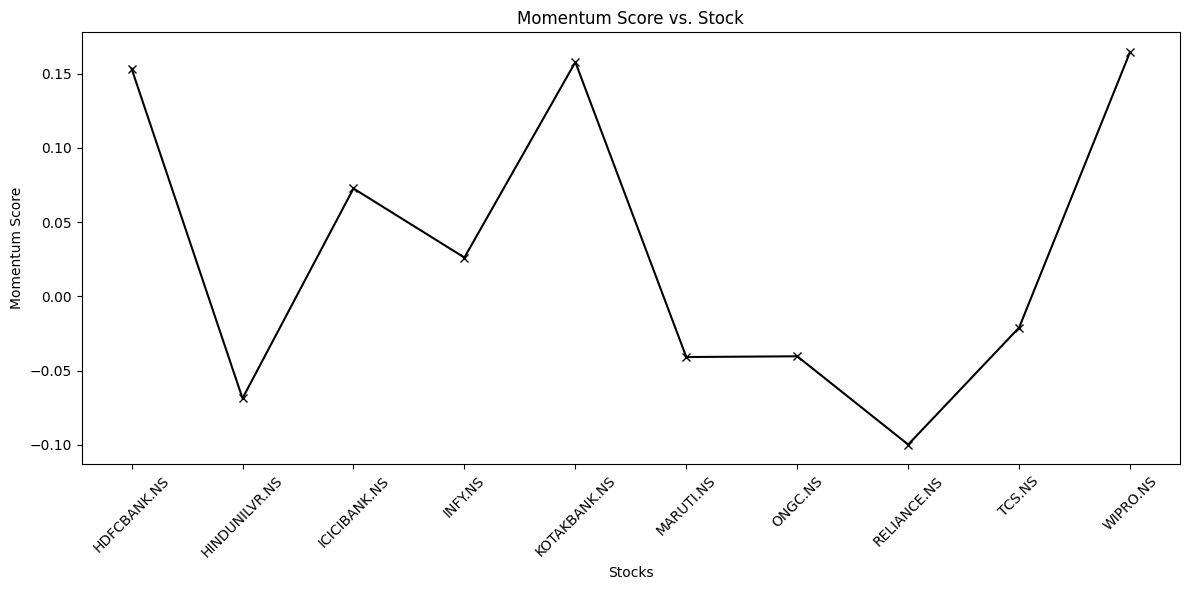

In [78]:
plt.figure(figsize=(12,6))

ax = latest.plot(
    kind="line",
    color="black",
    marker="x"
)

ax.set_xticks(range(len(latest.index)))
ax.set_xticklabels(latest.index, rotation=45)

plt.title("Momentum Score vs. Stock")
plt.ylabel("Momentum Score")
plt.xlabel("Stocks")
plt.tight_layout()
plt.savefig("../data/momentum_score_line_chart.png")
plt.show()

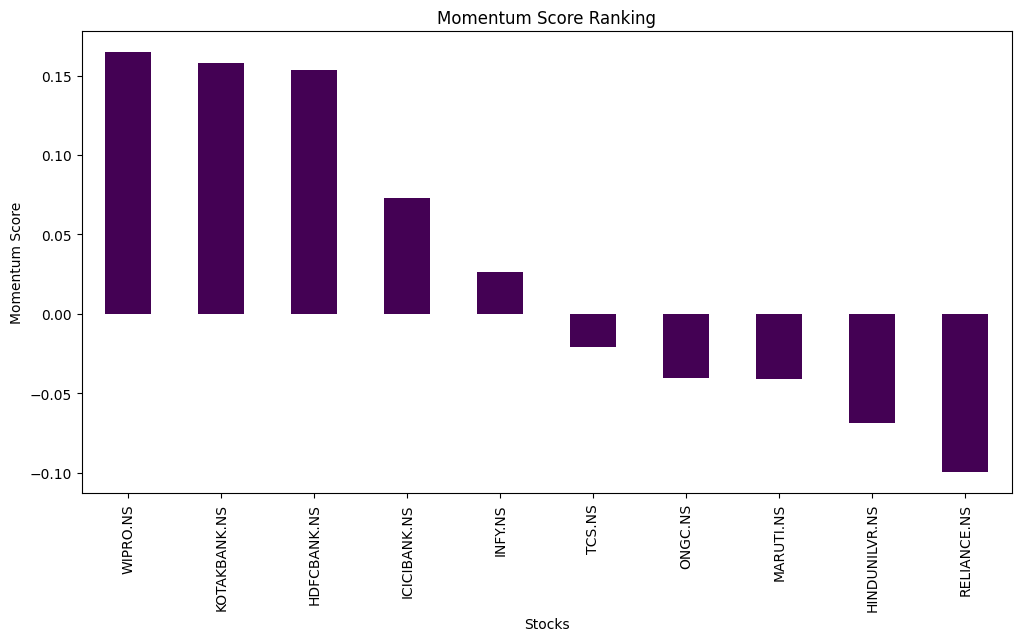

In [79]:
plt.figure(figsize=(12,6))

latest.sort_values(ascending=False).plot(
    kind="bar",
    colormap="viridis"
)

plt.title("Momentum Score Ranking")
plt.ylabel("Momentum Score")
plt.xlabel("Stocks")
plt.savefig("../data/bar_chart_momentum_score.png")
plt.show()
